# Week 2 Homework — The Credit Default Challenge

**Worked solution.** Every number quoted in the written answers is produced by the cell
above it — re-run the notebook and they regenerate.

Dataset: the ISLR `Default` book. 10,000 credit-card customers, with student status,
card balance and annual income. The question is who defaults.

Reproducibility note: the train/test split uses `random_state=1` and `stratify=y`.
Change either and every number below moves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, classification_report)

import warnings
# The lecture notebook's note applies: scikit-learn 1.8 deprecated the `penalty=` argument
# of LogisticRegression. We keep the old spelling (the brief asks for it) and silence only
# that one message. Nothing else is suppressed.
warnings.filterwarnings('ignore', message=".*'penalty' was deprecated.*")
warnings.filterwarnings('ignore', message=".*Inconsistent values: penalty.*")
warnings.filterwarnings('ignore', message=".*Workbook contains no default style.*")

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

import sklearn
print('scikit-learn', sklearn.__version__)

scikit-learn 1.9.1


# Part 1: EDA & Balance

## 1.1 Load the data, encode the categoricals

`index_col=0` matters here for the same reason it did in Week 1: the file carries an
unnamed first column that is only the row number. Without it you train on the row
number as a feature.

In [2]:
URL = ('https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/'
       'master/Notebooks/Data/Default.xlsx')

df = pd.read_excel(URL, index_col=0)
df['default'] = (df['default'] == 'Yes').astype(int)
df['student'] = (df['student'] == 'Yes').astype(int)

print(df.head())
print()
print(f'shape: {df.shape}')
print(df.dtypes.to_string())

   default  student      balance        income
1        0        0   729.526495  44361.625074
2        0        1   817.180407  12106.134700
3        0        0  1073.549164  31767.138947
4        0        0   529.250605  35704.493935
5        0        0   785.655883  38463.495879

shape: (10000, 4)
default      int64
student      int64
balance    float64
income     float64


## 1.2 The imbalance, and what a "dumb" model scores

In [3]:
n = len(df)
n_def = int(df['default'].sum())

print(f'defaulters   : {n_def} of {n}')
print(f'default rate : {100 * df["default"].mean():.2f}%')
print()

dumb = np.zeros(n, dtype=int)
print('THE DUMB MODEL — "nobody defaults"')
print(f'  accuracy : {accuracy_score(df["default"], dumb):.4f}')
print(f'  recall   : {recall_score(df["default"], dumb, zero_division=0):.4f}'
      f'   <- caught 0 of the {n_def} defaulters')

defaulters   : 333 of 10000
default rate : 3.33%

THE DUMB MODEL — "nobody defaults"
  accuracy : 0.9667
  recall   : 0.0000   <- caught 0 of the 333 defaulters


### Answer 1.2

**333 of 10,000 customers default — a base rate of 3.33%.**

A model that refuses to think and predicts "No Default" for everybody scores
**96.67% accuracy**. It would look like an excellent model on a slide and it is worth
exactly nothing: its recall is **0.000**, it catches none of the 333 defaulters, and a
bank deploying it would fund every single bad loan in the book.

This is the concrete version of the lecture's claim that accuracy is dangerous. The
number 96.67% is not a measure of skill — it is a restatement of the base rate. Any
model reported below has to beat 96.67% accuracy just to be *as useless as doing
nothing*, which is why accuracy is not the metric used anywhere else in this notebook.

## 1.3 Balance for defaulters vs non-defaulters

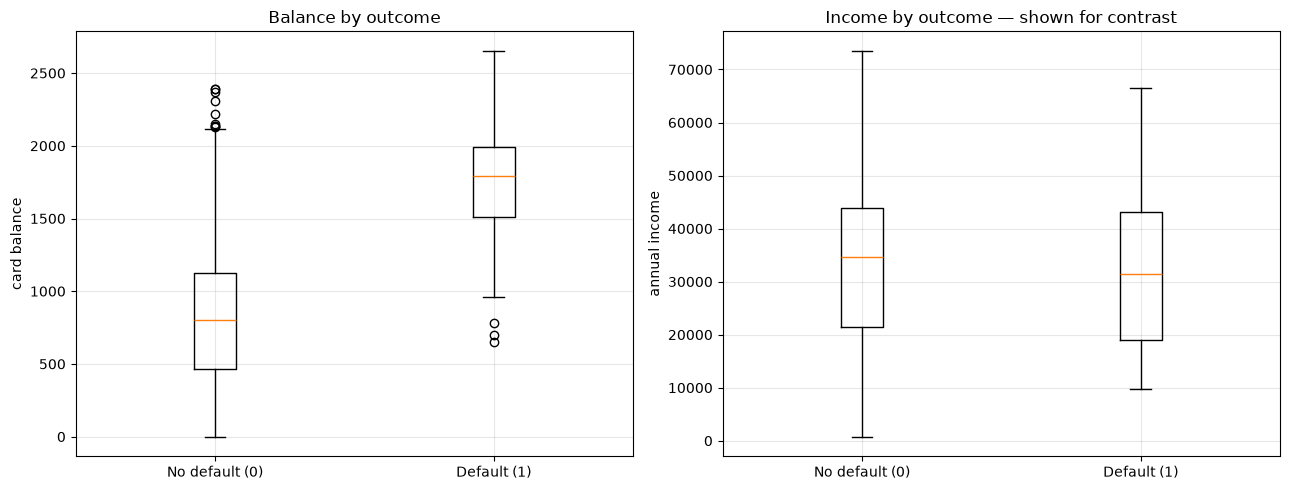

         balance   income
default                  
0          803.0  34589.0
1         1789.0  31515.0


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].boxplot([df.loc[df['default'] == 0, 'balance'],
               df.loc[df['default'] == 1, 'balance']],
              tick_labels=['No default (0)', 'Default (1)'])
ax[0].set_ylabel('card balance')
ax[0].set_title('Balance by outcome')
ax[0].grid(alpha=0.3)

ax[1].boxplot([df.loc[df['default'] == 0, 'income'],
               df.loc[df['default'] == 1, 'income']],
              tick_labels=['No default (0)', 'Default (1)'])
ax[1].set_ylabel('annual income')
ax[1].set_title('Income by outcome — shown for contrast')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(df.groupby('default')[['balance', 'income']].median().round(0).to_string())

### Answer 1.3

**Yes, emphatically.** Median balance is **1,789** for defaulters against **803** for
non-defaulters — more than double. The two boxes barely overlap: almost the whole
defaulter box sits above the non-defaulter upper quartile.

The income panel is included as a control and shows the opposite: medians of **31,515**
and **34,589**, two distributions sitting on top of each other. Income does almost
nothing to separate the classes.

That contrast is the substantive finding of Part 1, and Parts 2 and 3 both confirm it
from different directions — the logistic coefficients in 2.3, and the L1 selection in
2.4.

## 1.4 The scales

Keep the ratio below. It is the explanation for the KNN result in Part 3.1.

In [5]:
print(df[['balance', 'income', 'student']].std().to_string())

ratio = df['income'].std() / df['balance'].std()
print(f'\nincome sd / balance sd = {ratio:.1f}x')

balance      483.714985
income     13336.639563
student        0.455795

income sd / balance sd = 27.6x


### Answer 1.4

| feature | standard deviation |
|---|---|
| `balance` | 483.7 |
| `income` | 13,336.6 |
| `student` | 0.456 |

**The spread of `income` is 27.6x that of `balance`.**

Both are measured in the same currency, so this is not a units mismatch that a sensible
choice of units would fix — incomes genuinely vary over a far wider range than card
balances. Any method that measures distance in the raw feature space will therefore be
driven almost entirely by income. Part 3.1 is that prediction being tested.

# Part 2: Logistic Regression & Interpretability

## 2.1 Stratified 70/30 split

`stratify=y` forces the same 3.33% default rate into both halves. Without it, the 100
defaulters that land in the test set are a random draw and could easily be 80 or 120,
which moves recall by several points for reasons that have nothing to do with the model.

In [6]:
X = df[['student', 'balance', 'income']]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

print(f'train: {len(X_train)} rows, {y_train.sum()} defaulters ({100 * y_train.mean():.2f}%)')
print(f'test : {len(X_test)} rows, {y_test.sum()} defaulters ({100 * y_test.mean():.2f}%)')

train: 7000 rows, 233 defaulters (3.33%)
test : 3000 rows, 100 defaulters (3.33%)


## 2.2 Logistic regression inside a Pipeline

The scaler lives *inside* the pipeline. `fit` then fits it on the training fold only,
and `predict` applies the already-fitted scaler to the test data. Scaling the full
dataset before splitting would let the test set's mean and standard deviation influence
the training data — a leak that inflates every number reported afterwards.

In [7]:
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)

print(logreg)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])


## 2.3 Coefficients

In [8]:
lr_final = logreg.steps[-1][1]
coefs = pd.Series(lr_final.coef_[0], index=X.columns)

print('coefficients (standardised features — log-odds per 1 sd):')
print(coefs.round(4).to_string())
print(f'\nintercept: {lr_final.intercept_[0]:.4f}')
print('\nodds multiplier per +1 sd:')
print(np.exp(coefs).round(4).to_string())

coefficients (standardised features — log-odds per 1 sd):
student   -0.1494
balance    2.6862
income     0.1585

intercept: -6.0000

odds multiplier per +1 sd:
student     0.8612
balance    14.6752
income      1.1718


### Answer 2.3

| feature | coefficient | odds multiplier per +1 sd |
|---|---|---|
| `balance` | **+2.686** | **14.68x** |
| `income` | +0.159 | 1.17x |
| `student` | −0.149 | 0.86x |

**Balance creates far more risk than income** — about **17 times** the coefficient
magnitude. In business terms, a customer one standard deviation (about EUR 484) above
the mean balance has roughly **14.7 times** the odds of default; one standard deviation
of extra income (about EUR 13,300) multiplies the odds by only 1.17.

**Being a student *reduces* risk in this model** — the coefficient is negative, an odds
multiplier of 0.86.

That last result deserves care, because it reverses if you look at students on their
own. The unconditional numbers say students are *worse*: **4.31%** of students default
against **2.92%** of non-students. The model says the opposite because it holds balance
fixed, and students carry higher balances (mean **988** vs **772**). Within any given
balance band, the student defaults *less*: in the top balance quintile, 14.4% against
16.1%.

So both statements are true and they answer different questions. "Are students riskier
customers?" — yes. "Given two customers with the same balance, is the student riskier?"
— no. A regression coefficient always answers the second. Confusing the two is how a
credit policy ends up rejecting the wrong group. (This is the textbook confounding
example from ISLR §4.3, and it is in this dataset on purpose.)

**Why scaling makes the coefficients comparable.** After standardisation every
coefficient means "change in log-odds per one standard deviation of this feature", so
they share a unit and can be ranked against each other. On the raw data they would mean
"per one euro of balance" and "per one euro of income" — and since a euro of balance is
a 27.6x bigger move relative to that variable's spread (Part 1.4), the raw balance
coefficient would be inflated by roughly that factor for reasons of arithmetic, not
risk. Ranking raw coefficients measures the units you happened to choose.

In [9]:
# The confounding claim above, verified rather than asserted.
print('unconditional default rate by student status:')
print(df.groupby('student')['default'].mean().round(4).to_string())
print('\nmean balance by student status:')
print(df.groupby('student')['balance'].mean().round(1).to_string())
print('\ndefault rate by balance quintile x student status:')
print(df.assign(balance_quintile=pd.qcut(df['balance'], 5))
        .pivot_table(index='balance_quintile', columns='student',
                     values='default', aggfunc='mean', observed=True).round(4).to_string())

unconditional default rate by student status:
student
0    0.0292
1    0.0431

mean balance by student status:
student
0    771.8
1    987.8

default rate by balance quintile x student status:
student                    0       1
balance_quintile                    
(-0.001, 395.378]     0.0000  0.0000
(395.378, 697.157]    0.0007  0.0000
(697.157, 951.25]     0.0014  0.0000
(951.25, 1249.788]    0.0138  0.0072
(1249.788, 2654.323]  0.1606  0.1439


## 2.4 Feature selection with L1 (Lasso)

In [10]:
for C in [1.0, 0.1, 0.01, 0.005]:
    m = make_pipeline(StandardScaler(),
                      LogisticRegression(penalty='l1', solver='liblinear', C=C))
    m.fit(X_train, y_train)
    c = pd.Series(m.steps[-1][1].coef_[0], index=X.columns)
    print(f'C={C:<6} zeros={int((c == 0).sum())}/3   '
          + '   '.join(f'{k}={v:+.4f}' for k, v in c.items()))

lasso = make_pipeline(StandardScaler(),
                      LogisticRegression(penalty='l1', solver='liblinear', C=0.01))
lasso.fit(X_train, y_train)
print('\nC=0.01, as the brief asks:')
print(pd.Series(lasso.steps[-1][1].coef_[0], index=X.columns).round(4).to_string())

C=1.0    zeros=0/3   student=-0.1514   balance=+2.6856   income=+0.1539
C=0.1    zeros=0/3   student=-0.0912   balance=+2.3399   income=+0.1126
C=0.01   zeros=2/3   student=+0.0000   balance=+1.0606   income=+0.0000
C=0.005  zeros=2/3   student=+0.0000   balance=+0.5546   income=+0.0000

C=0.01, as the brief asks:
student    0.0000
balance    1.0606
income     0.0000


### Answer 2.4

**Yes — at `C=0.01`, two of the three coefficients drop to exactly zero.** `student` and
`income` are switched off entirely, leaving `balance` alone at **+1.061**.

Note that this depends on the penalty strength, and the sweep above shows it: at `C=1.0`
and `C=0.1` nothing is zeroed at all. In `LogisticRegression`, `C` is the *inverse*
penalty, so small `C` means a strong penalty — the opposite direction to `alpha` in
Week 1's Ridge and Lasso. Mixing the two up is an easy way to conclude that L1 "doesn't
select anything".

**What it implies:** balance carries essentially all the usable signal. When forced to
economise, the model spends its entire budget there and discards the other two — which
agrees with the boxplots in 1.3 and the coefficient ranking in 2.3. Three independent
routes to the same conclusion.

**The caveat from the Week 1 lecture still applies:** a zero coefficient is not proof
that a variable does not matter. L1 drops whichever of a correlated group it finds
convenient, and the choice can flip with a small change in the data. Here it is
believable because balance wins under every other test too — but the zero on its own
would not be evidence.

# Part 3: The Metric Battle — Logistic Regression vs KNN

## 3.1 KNN, scaled and unscaled

In [11]:
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=9))
knn.fit(X_train, y_train)

knn_raw = KNeighborsClassifier(n_neighbors=9)
knn_raw.fit(X_train, y_train)

for name, m in [('KNN k=9 (scaled)', knn), ('KNN k=9 (RAW)', knn_raw)]:
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f'{name:<20} accuracy {accuracy_score(y_test, pred):.4f}   '
          f'recall {recall_score(y_test, pred, zero_division=0):.4f}   '
          f'AUC {roc_auc_score(y_test, proba):.4f}   '
          f'caught {tp} of {tp + fn} defaulters')

KNN k=9 (scaled)     accuracy 0.9737   recall 0.4100   AUC 0.8818   caught 41 of 100 defaulters


KNN k=9 (RAW)        accuracy 0.9673   recall 0.0600   AUC 0.8766   caught 6 of 100 defaulters


### Answer 3.1

| model | accuracy | recall | AUC | defaulters caught |
|---|---|---|---|---|
| KNN k=9, **scaled** | 0.9737 | **0.410** | 0.882 | 41 of 100 |
| KNN k=9, **raw** | 0.9673 | **0.060** | 0.877 | 6 of 100 |

**Recall collapses from 0.41 to 0.06** — the unscaled model finds 6 defaulters where the
scaled one finds 41.

Look at what accuracy does while that happens: it falls from 0.974 to 0.967, a drop of
less than one point, and **0.967 is the dumb model's score from Part 1.2**. On accuracy
alone the unscaled model looks fine. It is in fact almost exactly as useful as predicting
"no default" for everybody. This is the Part 1.2 lesson arriving in a real comparison.

**Why, using the standard deviations from 1.4.** KNN classifies by Euclidean distance.
On raw features that distance is

$$d = \sqrt{(\Delta \text{balance})^2 + (\Delta \text{income})^2 + (\Delta \text{student})^2}$$

and since income varies **27.6x** more widely than balance, a typical income gap is
~27.6x larger than a typical balance gap. Squared, it dominates by a factor of roughly
**760**. The "nearest neighbours" are therefore chosen almost entirely on income — the
one feature that Part 1.3 showed barely separates the classes — while balance, which
carries the signal, contributes almost nothing. `student`, with a standard deviation of
0.46, is invisible.

`StandardScaler` divides each feature by its own standard deviation, so a one-sd move
counts the same in every direction and balance can compete. This is why KNN belongs in
a pipeline and logistic regression only benefits from one: the scaler changes what KNN
*is*, whereas it only changes how a logistic coefficient is *expressed*.

## 3.2 Confusion matrices and the metric table

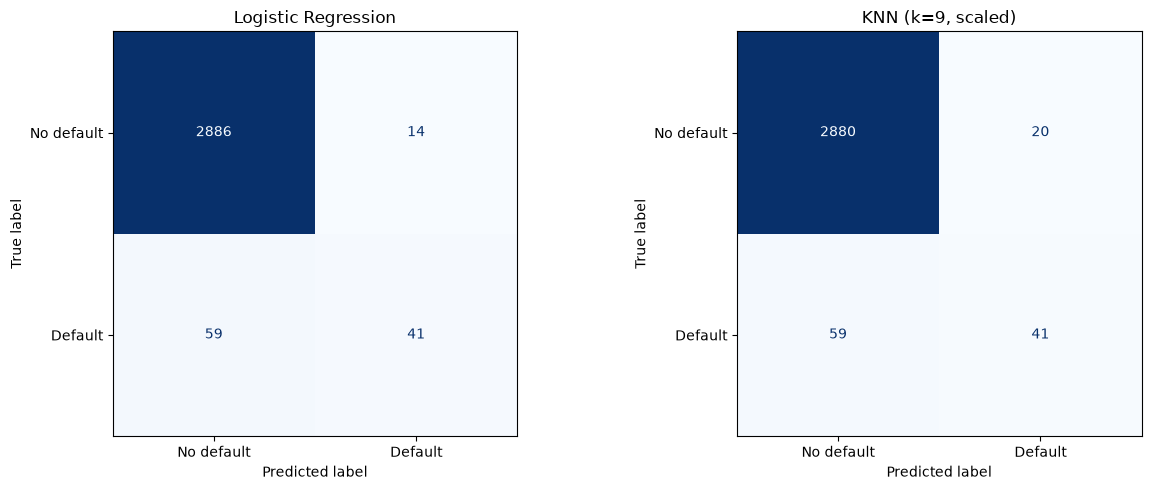

All metrics for the Default=1 class:
                     Accuracy  Recall  Precision      F1  ROC-AUC  FN (funded a defaulter)  FP (refused a good customer)
Model                                                                                                                   
Logistic Regression    0.9757    0.41     0.7455  0.5290   0.9586                       59                            14
KNN (k=9, scaled)      0.9737    0.41     0.6721  0.5093   0.8818                       59                            20

--- Logistic Regression ---
              precision    recall  f1-score   support

  No default       0.98      1.00      0.99      2900
     Default       0.75      0.41      0.53       100

    accuracy                           0.98      3000
   macro avg       0.86      0.70      0.76      3000
weighted avg       0.97      0.98      0.97      3000

--- KNN (k=9, scaled) ---
              precision    recall  f1-score   support

  No default       0.98      0.99      0.9

In [12]:
models = {'Logistic Regression': logreg, 'KNN (k=9, scaled)': knn}

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, (name, m) in enumerate(models.items()):
    cm = confusion_matrix(y_test, m.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['No default', 'Default']).plot(
        cmap='Blues', ax=ax[i], colorbar=False)
    ax[i].set_title(name)
plt.tight_layout()
plt.show()

rows = []
for name, m in models.items():
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({'Model': name,
                 'Accuracy': accuracy_score(y_test, pred),
                 'Recall': recall_score(y_test, pred, zero_division=0),
                 'Precision': precision_score(y_test, pred, zero_division=0),
                 'F1': f1_score(y_test, pred, zero_division=0),
                 'ROC-AUC': roc_auc_score(y_test, proba),
                 'FN (funded a defaulter)': fn,
                 'FP (refused a good customer)': fp})

metrics = pd.DataFrame(rows).set_index('Model')
print('All metrics for the Default=1 class:')
print(metrics.round(4).to_string())

print()
for name, m in models.items():
    print(f'--- {name} ---')
    print(classification_report(y_test, m.predict(X_test),
                                target_names=['No default', 'Default'], zero_division=0))

## 3.3 The trade-off analysis

### Answer 3.3

| metric | Logistic Regression | KNN (k=9) | winner |
|---|---|---|---|
| Recall | 0.410 | 0.410 | **tie** |
| Precision | **0.745** | 0.672 | Logistic |
| F1 | **0.529** | 0.509 | Logistic |
| ROC-AUC | **0.959** | 0.882 | Logistic |
| False negatives | 59 | 59 | tie |
| False positives | **14** | 20 | Logistic |

**Recall — which model is safer?** *Neither, at this threshold.* Both catch 41 of the
100 defaulters and miss 59. That is an honest tie, not a rounding artefact, and it is
worth resisting the temptation to break it: the interesting fact is that **both models
miss well over half the defaults** at the default cut of 0.5. Part 4 is where that gets
fixed, and it is fixed without touching either model.

**Precision — which model is more efficient?** Logistic regression, **0.745 vs 0.672**.
Of the customers it refuses, three in four really would have defaulted; KNN is right
two times in three. In absolute terms KNN wrongly refuses 20 good customers against
logistic regression's 14 — 43% more lost business for the same number of defaults
caught.

**F1 — the best balance?** Logistic regression, 0.529 vs 0.509, which follows directly
from tied recall and better precision.

**The metric that separates them properly is AUC: 0.959 vs 0.882.** The point-metrics
above all describe behaviour at the arbitrary 0.5 cut. AUC describes the *ranking* —
how well the model sorts risky customers above safe ones, independently of where you
cut. A 0.077 gap in AUC says logistic regression's probabilities carry materially more
information, and Part 4 is what converts that into money.

## 3.4 ROC curves

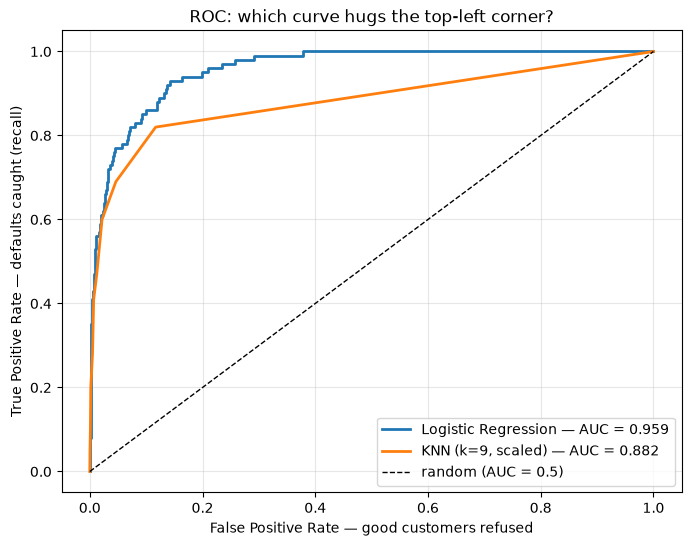

In [13]:
plt.figure(figsize=(8, 6))
for name, m in models.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} — AUC = {auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='random (AUC = 0.5)')
plt.xlabel('False Positive Rate — good customers refused')
plt.ylabel('True Positive Rate — defaults caught (recall)')
plt.title('ROC: which curve hugs the top-left corner?')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Answer 3.4

**The logistic regression curve is closer to the top-left**, and by a visible margin —
AUC **0.959** against **0.882**.

The gap is widest in the region that matters. On the left of the plot, where the false
positive rate is low (the bank refuses few good customers), logistic regression already
reaches a high true positive rate while KNN is still climbing. That left-hand region is
where a real lender operates, so the gap in deployed performance is wider than the
single AUC number suggests.

The KNN curve is also visibly **stepped** rather than smooth. With k=9 it can only
produce ten distinct scores, so the curve has ten corners and the sweep cannot land
anywhere between them. Part 4.4 is about what that costs.

## 3.5 The Verdict

### Answer 3.5

**Scenario A — conservative bank, fears losing principal, needs high recall.**
**Logistic regression**, but not because of the recall column, which is tied at 0.41.
It wins because recall at a *fixed* threshold is the wrong thing to compare. Recall is
something you buy by lowering the threshold, and the price is false positives; the
exchange rate is set by the ROC curve. With AUC 0.959 against 0.882, logistic regression
buys recall more cheaply at every level. Part 4 makes this concrete: dropping its
threshold to 0.06 lifts recall from 0.41 to **0.85** — and Part 4.4 shows KNN cannot
even be tuned to that point.

**Scenario B — growth bank, fears rejecting good customers, needs high precision.**
**Logistic regression**, directly this time: precision **0.745 vs 0.672**, and 14 false
positives against 20 for the same 41 defaults caught. There is no trade-off to weigh —
it is simply better on the metric named.

**Final decision for a regulated financial institution: logistic regression.** Three
reasons, in order of how much they would matter to a regulator:

1. **Explainability.** The model is three coefficients and an intercept. It can state
   that balance drives risk with an odds multiplier of 14.7 per standard deviation, and
   it can give any rejected applicant a specific reason. KNN's explanation for a refusal
   is "six of your nine nearest neighbours defaulted", which is not an adverse-action
   notice and will not satisfy a model-risk review.
2. **Performance.** Equal or better on every metric measured — tied recall, better
   precision, better F1, materially better AUC.
3. **Operational control.** Its probabilities are continuous, so the threshold can be
   placed wherever the cost analysis says. Part 4.4 shows KNN's cannot.

The honest caveat: this comparison is one train/test split with `random_state=1`, and
KNN was given k=9 as the brief specified rather than a tuned value. A fairer contest
would cross-validate k on the training set. It would not change the explainability
argument, which is what decides this in a regulated setting.

# Part 4: The Threshold

## 4.1 / 4.2 — Sweep the threshold and cost every outcome

A false negative (we funded someone who defaulted) costs **EUR 20,000**; a false
positive (we refused someone who would have repaid) costs **EUR 1,000**. One missed
default is worth twenty unnecessary refusals.

In [14]:
COST_FN = 20_000
COST_FP = 1_000

proba_lr = logreg.predict_proba(X_test)[:, 1]

rows = []
for t in np.arange(0.02, 0.61, 0.02):
    pred = (proba_lr >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({'threshold': round(t, 2), 'FN': fn, 'FP': fp,
                 'recall': tp / (tp + fn),
                 'cost': COST_FN * fn + COST_FP * fp})

costs = pd.DataFrame(rows)
print(costs.to_string(index=False))

 threshold  FN  FP  recall    cost
      0.02   6 563    0.94  683000
      0.04  11 377    0.89  597000
      0.06  15 271    0.85  571000
      0.08  18 216    0.82  576000
      0.10  22 185    0.78  625000
      0.12  23 155    0.77  615000
      0.14  23 134    0.77  594000
      0.16  26 119    0.74  639000
      0.18  27 105    0.73  645000
      0.20  31  91    0.69  711000
      0.22  34  78    0.66  758000
      0.24  39  65    0.61  845000
      0.26  39  59    0.61  839000
      0.28  41  56    0.59  876000
      0.30  43  51    0.57  911000
      0.32  44  40    0.56  920000
      0.34  44  33    0.56  913000
      0.36  49  27    0.51 1007000
      0.38  51  26    0.49 1046000
      0.40  54  22    0.46 1102000
      0.42  56  20    0.44 1140000
      0.44  58  17    0.42 1177000
      0.46  58  16    0.42 1176000
      0.48  59  16    0.41 1196000
      0.50  59  14    0.41 1194000
      0.52  60  12    0.40 1212000
      0.54  61  11    0.39 1231000
      0.56  64  10  

## 4.3 The cost-minimising threshold

In [15]:
best = costs.loc[costs['cost'].idxmin()]
row50 = costs.loc[np.isclose(costs['threshold'], 0.50)].iloc[0]

print(f'cheapest threshold  : {best.threshold:.2f}  ->  EUR {best.cost:>10,.0f}   '
      f'(recall {best.recall:.2f},  FN {int(best.FN)},  FP {int(best.FP)})')
print(f'the default    0.50 :        ->  EUR {row50.cost:>10,.0f}   '
      f'(recall {row50.recall:.2f},  FN {int(row50.FN)},  FP {int(row50.FP)})')
print(f'cost of not choosing:        ->  EUR {row50.cost - best.cost:>10,.0f}')
print(f'                             ->  EUR {(row50.cost - best.cost) / len(y_test):,.0f} '
      f'per application, across {len(y_test)} customers')

cheapest threshold  : 0.06  ->  EUR    571,000   (recall 0.85,  FN 15,  FP 271)
the default    0.50 :        ->  EUR  1,194,000   (recall 0.41,  FN 59,  FP 14)
cost of not choosing:        ->  EUR    623,000
                             ->  EUR 208 per application, across 3000 customers


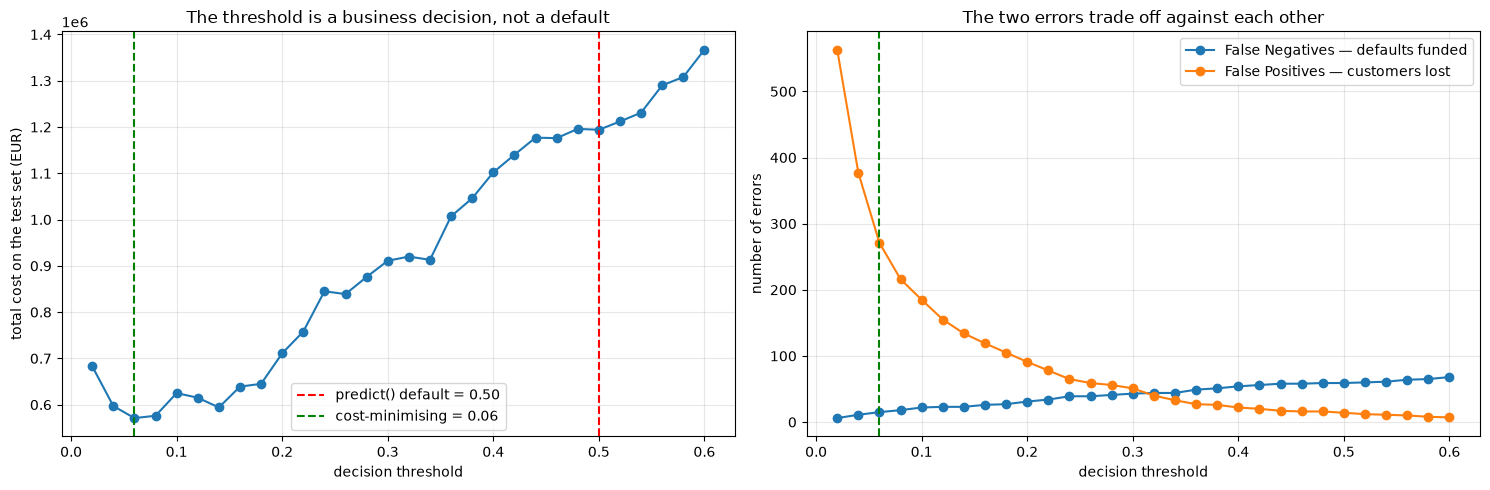

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(costs['threshold'], costs['cost'], marker='o')
ax[0].axvline(0.5, ls='--', c='red', label='predict() default = 0.50')
ax[0].axvline(best.threshold, ls='--', c='green',
              label=f'cost-minimising = {best.threshold:.2f}')
ax[0].set_xlabel('decision threshold')
ax[0].set_ylabel('total cost on the test set (EUR)')
ax[0].set_title('The threshold is a business decision, not a default')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(costs['threshold'], costs['FN'], marker='o', label='False Negatives — defaults funded')
ax[1].plot(costs['threshold'], costs['FP'], marker='o', label='False Positives — customers lost')
ax[1].axvline(best.threshold, ls='--', c='green')
ax[1].set_xlabel('decision threshold')
ax[1].set_ylabel('number of errors')
ax[1].set_title('The two errors trade off against each other')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Answer 4.3

| | threshold | total cost | recall | FN | FP |
|---|---|---|---|---|---|
| cost-minimising | **0.06** | **EUR 571,000** | 0.85 | 15 | 271 |
| library default | 0.50 | EUR 1,194,000 | 0.41 | 59 | 14 |
| **difference** | | **EUR 623,000** | | | |

**Moving the threshold from 0.50 to 0.06 saves EUR 623,000** on 3,000 customers — about
**EUR 208 per application** — and lifts recall from 0.41 to 0.85. The bank goes from
catching 41 of 100 defaulters to catching 85.

It pays for this with 271 false positives instead of 14. At a 20:1 cost ratio that is a
good trade: 257 extra refusals cost EUR 257,000, while the 44 extra defaults caught save
EUR 880,000.

**The model did not change.** Same coefficients, same probabilities, same AUC of 0.959.
Only the decision rule moved. AUC could not have revealed any of this, because AUC is
invariant to the threshold by construction — it is the same number at 0.06 and at 0.50.
EUR 623,000 was sitting in a single default argument nobody chose.

**The curve has a genuine interior minimum.** Below 0.06 the cost rises again: at 0.02
the bank catches 94 defaulters but refuses 563 good customers, for EUR 683,000. More
recall is not free, and "maximise recall" is not the answer either.

**Health warning — this threshold is not trustworthy as reported.** The sweep ran on the
*test* set, which is the same mistake as tuning `alpha` on the test set in Week 1: the
0.06 is fitted to this particular 3,000 customers and EUR 571,000 is optimistic. Done
properly, you split a validation set off the training data, choose the threshold there,
and report the cost on the untouched test set. The direction of the conclusion is safe
— 0.50 is badly wrong for a 3.3% base rate — but the exact figure would move.

## 4.4 Could KNN implement this threshold?

In [17]:
proba_knn = knn.predict_proba(X_test)[:, 1]
vals = np.unique(proba_knn)

print(f'KNN (k=9) distinct probabilities on the test set: {len(vals)}')
print(vals.round(4))
print(f'\nLogistic regression distinct probabilities: {len(np.unique(proba_lr))}')

below = vals[vals <= best.threshold].max()
above = vals[vals > best.threshold].min()
print(f'\noptimal threshold from 4.3          : {best.threshold:.2f}')
print(f'nearest KNN values either side      : {below:.4f} and {above:.4f}')
print(f'  -> every threshold in ({below:.4f}, {above:.4f}] gives the identical classifier')

KNN (k=9) distinct probabilities on the test set: 10
[0.     0.1111 0.2222 0.3333 0.4444 0.5556 0.6667 0.7778 0.8889 1.    ]

Logistic regression distinct probabilities: 3000

optimal threshold from 4.3          : 0.06
nearest KNN values either side      : 0.0000 and 0.1111
  -> every threshold in (0.0000, 0.1111] gives the identical classifier


KNN cost curve — note the flat plateaus:
 threshold  FN  FP    cost
      0.02  18 339  699000
      0.04  18 339  699000
      0.06  18 339  699000
      0.08  18 339  699000
      0.10  18 339  699000
      0.12  31 134  754000
      0.14  31 134  754000
      0.16  31 134  754000
      0.18  31 134  754000
      0.20  31 134  754000
      0.22  31 134  754000
      0.24  40  63  863000
      0.26  40  63  863000
      0.28  40  63  863000
      0.30  40  63  863000
      0.32  40  63  863000
      0.34  53  36 1096000
      0.36  53  36 1096000
      0.38  53  36 1096000
      0.40  53  36 1096000
      0.42  53  36 1096000
      0.44  53  36 1096000
      0.46  59  20 1200000
      0.48  59  20 1200000
      0.50  59  20 1200000
      0.52  59  20 1200000
      0.54  59  20 1200000
      0.56  72  14 1454000
      0.58  72  14 1454000
      0.60  72  14 1454000


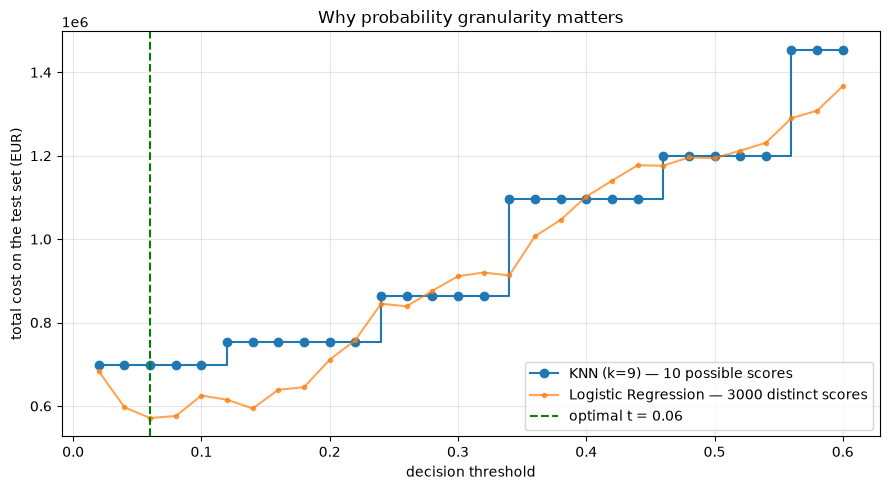

In [18]:
knn_rows = []
for t in np.arange(0.02, 0.61, 0.02):
    pred = (proba_knn >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    knn_rows.append({'threshold': round(t, 2), 'FN': fn, 'FP': fp,
                     'cost': COST_FN * fn + COST_FP * fp})
knn_costs = pd.DataFrame(knn_rows)

print('KNN cost curve — note the flat plateaus:')
print(knn_costs.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.step(knn_costs['threshold'], knn_costs['cost'], where='post',
         marker='o', label='KNN (k=9) — 10 possible scores')
plt.plot(costs['threshold'], costs['cost'], marker='.', alpha=0.7,
         label='Logistic Regression — 3000 distinct scores')
plt.axvline(best.threshold, ls='--', c='green', label=f'optimal t = {best.threshold:.2f}')
plt.xlabel('decision threshold')
plt.ylabel('total cost on the test set (EUR)')
plt.title('Why probability granularity matters')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Answer 4.4

**KNN with k=9 produces exactly 10 distinct probability values** — 0, 1/9, 2/9, ... 1 —
and all ten appear in the test set. It cannot produce anything else: the predicted
probability is the fraction of the 9 nearest neighbours that defaulted, so the
denominator is always 9. Logistic regression produces **3,000** distinct values on the
same 3,000 customers.

**No, the optimal threshold of 0.06 cannot be implemented with this model — not
meaningfully.** The nearest KNN values either side of 0.06 are **0.0000** and **0.1111**,
so *every* threshold in the interval (0, 0.1111] produces the identical classifier.
Setting the cut to 0.06 is not an error, it simply does nothing different from setting
it to 0.02 or 0.11: it means "flag anyone with at least one defaulting neighbour". The
cost table confirms it — five consecutive thresholds from 0.02 to 0.10 all return
exactly EUR 699,000. The KNN cost curve is a step function with nine reachable levels,
and the bank's chosen operating point falls in the middle of a step.

The consequence is that the best KNN can do anywhere in that region is EUR 699,000,
against logistic regression's EUR 571,000 — **EUR 128,000 worse**, purely from being
unable to cut where it wants to. That is a fourth, independent argument for logistic
regression in Part 3.5, and it is about the *granularity* of the probabilities rather
than their quality.

Raising k would help — k=100 gives 101 levels — but it trades away local resolution, and
a KNN score is still a neighbour count rather than a calibrated probability. If the
decision rule is a threshold on a probability, use a model that emits real probabilities.